In [1]:
import seaborn as sns

df = sns.load_dataset("titanic")

In [2]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
## Deleting the rows or data point can cause a huge amount of data loss

df.shape

(891, 15)

In [ ]:
df.dropna().shape

(182, 15)

In [13]:
### columnwise deletion

df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


In [18]:
df.isnull().sum()

survived      0
pclass        0
sex           0
sibsp         0
parch         0
fare          0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

In [20]:
import seaborn as sns

df = sns.load_dataset("titanic")

<Axes: xlabel='age', ylabel='Count'>

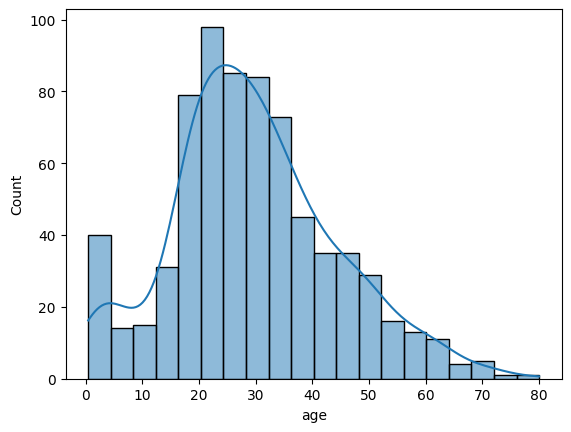

In [21]:
### Imputation techniques 
## Mean Value Imputation(Replacing the missing values with the mean)

sns.histplot(df['age'], kde=True)

In [24]:
df['Age_Mean'] = df['age'].fillna(df['age'].mean())

In [26]:
df[['Age_Mean' , 'age']]

,Age_Mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [28]:
### Median Value Imputation(Presence of Outliers within the dataset)

df['Age_Median'] = df['age'].fillna(df['age'].median())

In [30]:
df[['Age_Mean' , 'Age_Median' , 'age']]

,Age_Mean,Age_Median,age
0,22.000000,22.0,22.0
1,38.000000,38.0,38.0
2,26.000000,26.0,26.0
3,35.000000,35.0,35.0
4,35.000000,35.0,35.0
...,...,...,...
886,27.000000,27.0,27.0
887,19.000000,19.0,19.0
888,29.699118,28.0,NaN
889,26.000000,26.0,26.0


In [32]:
### Mode Imputation Technique

df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Mean,Age_Median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [33]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [37]:
df[df['embarked'].notna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Mean,Age_Median
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.000000,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.000000,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.000000,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.000000,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.000000,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,27.000000,27.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,19.000000,19.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,29.699118,28.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,26.000000,26.0


In [38]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

In [39]:
df['embarked_mode'] = df['embarked'].fillna(mode_value)

In [40]:
df[['embarked_mode' , 'embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [41]:
## Handling Imbalance Dataset

import numpy as np
import pandas as pd

np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.8

n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [42]:
n_class_0, n_class_1

(800, 200)

In [50]:
## Creating an imbalanced dataset

class_0 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'target' : [0] * n_class_0
 })


class_1 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_1),
    'target' : [1] * n_class_1
 })

In [58]:
df = pd.concat([class_0 , class_1]).reset_index(drop=True)

In [60]:
df.head()

,feature_1,feature_2,target
0,-0.548418,-0.955471,0
1,1.065383,0.553504,0
2,-0.523922,1.689880,0
3,0.545988,-0.262399,0
4,-0.565880,-0.802446,0


In [ ]:
## Upsampling 

df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

(200, 3)

In [62]:
from sklearn.utils import resample
df_minority_resampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

In [63]:
df_minority_resampled.shape

(800, 3)

In [66]:
df_upsampled = pd.concat([df_majority, df_minority_resampled])

In [67]:
df_upsampled['target'].value_counts()

target
0    800
1    800
Name: count, dtype: int64

In [68]:
### Down Sampling

class_0 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'target' : [0] * n_class_0
 })


class_1 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_1),
    'target' : [1] * n_class_1
 })

In [73]:
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [74]:
from sklearn.utils import resample
df_majority_resampled = resample(df_majority, replace=True, n_samples=len(df_minority), random_state=42)

In [75]:
df_majority_resampled.shape

(200, 3)

In [76]:
df_downsampled = pd.concat([df_minority, df_majority_resampled])

In [78]:
df_downsampled.target.value_counts()

target
1    200
0    200
Name: count, dtype: int64

In [83]:
from sklearn.datasets import make_classification

In [86]:
X,y = make_classification(n_samples=1000, n_redundant=0, n_features=2, n_clusters_per_class=1, weights=[0.90], random_state=12)

In [87]:
df1 = pd.DataFrame(X,columns=['feature1','feature2'])
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df.head()

,feature1,feature2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [89]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

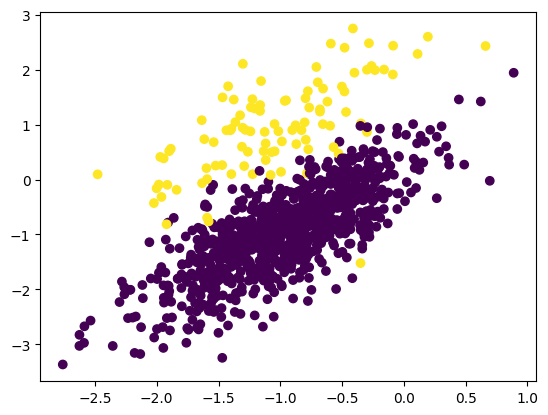

In [91]:
import matplotlib.pyplot as plt
plt.scatter(final_df['feature1'],final_df['feature2'],c=final_df['target'])


In [92]:
from imblearn.over_sampling import SMOTE

In [105]:
oversample = SMOTE()
X,y= oversample.fit_resample(final_df[['feature1','feature2']],final_df['target'])

In [95]:
X.shape

(1800, 2)

In [96]:
y.shape

(1800,)

In [97]:
len(y[y==0])

900

In [98]:
len(y[y==1])

900

In [108]:
df1 = pd.DataFrame(X,columns=['feature1','feature2'])
df2 = pd.DataFrame(y,columns=['target'])
oversample_df = pd.concat([df1,df2],axis=1)

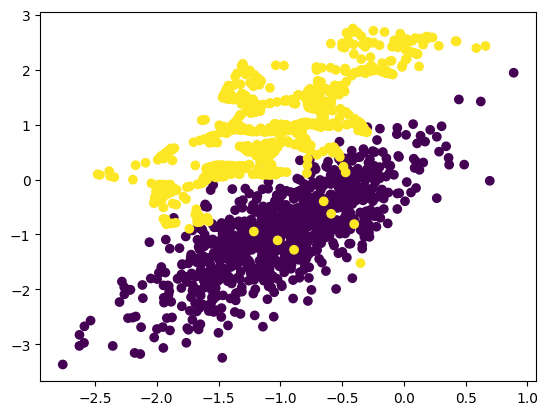

In [109]:
plt.scatter(oversample_df['feature1'],oversample_df['feature2'],c=oversample_df['target'])

In [110]:
## 5 Number Summary

import numpy as np

In [111]:
lst_ages=[20,29,31,25,46,67,84,33,21,19,53,77,81,94,16]
minimum,Q1,median,Q3,maximum = np.quantile(lst_ages,[0,0.25,0.50,0.75,1.0])

In [119]:
minimum,Q1,median,Q3,maximum

(16.0, 23.0, 33.0, 72.0, 94.0)

In [120]:
IQR = Q3-Q1
IQR

49.0

In [121]:
lower_fence  = Q1 - 1.5 * (IQR)
higher_fence = Q3 + 1.5 * (IQR)

In [122]:
lower_fence,higher_fence

(-50.5, 145.5)

<Axes: >

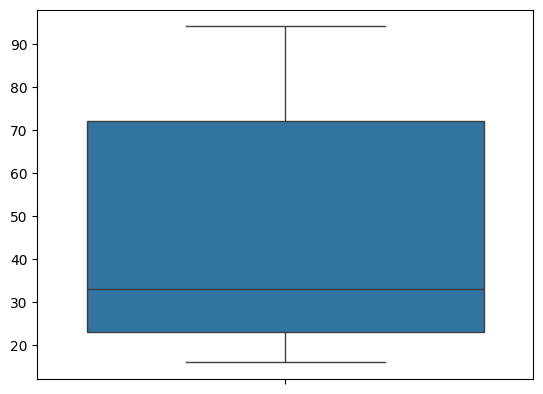

In [123]:
sns.boxplot(lst_ages)

In [126]:
lst_ages=[-70,-50,20,29,31,25,46,67,84,33,21,19,53,77,81,94,16,150,170]

<Axes: >

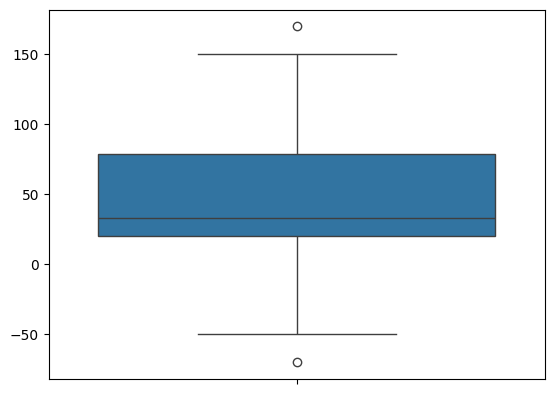

In [127]:
sns.boxplot(lst_ages)

In [128]:
## Data Encoding

from sklearn.preprocessing import OneHotEncoder

In [129]:
df = pd.DataFrame({'color' : ['red','green','blue','red','blue' ] })

In [130]:
df.head()

,color
0,red
1,green
2,blue
3,red
4,blue


In [131]:
encoder = OneHotEncoder()

In [136]:
encoded = encoder.fit_transform(df[['color']]).toarray()

In [138]:
encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [139]:
encoded_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0


In [140]:
tips = sns.load_dataset('tips')

In [167]:
tips['smoker']

0       No
1       No
2       No
3       No
4       No
      ... 
239     No
240    Yes
241    Yes
242     No
243     No
Name: smoker, Length: 244, dtype: category
Categories (2, str): ['Yes', 'No']

In [153]:
encoder = OneHotEncoder()

In [156]:
encoded = encoder.fit_transform(tips[['smoker']]).toarray()

In [165]:
encoded_tips = pd.DataFrame(encoded,columns=["Yes","No"])

In [166]:
encoded_tips

,Yes,No
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
239,1.0,0.0
240,0.0,1.0
241,0.0,1.0
242,1.0,0.0
